In [1]:
# Import necessary libraries
import kagglehub
from kagglehub import KaggleDatasetAdapter
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
from collections import Counter
import re
from sklearn.preprocessing import MultiLabelBinarizer

# Set the style for the plots
plt.style.use('ggplot')
sns.set(style="whitegrid")

# For reproducibility
np.random.seed(42)

pd.set_option('display.max_colwidth', 200)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data from Kaggle

In [2]:
# Load data
edges = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "edges.csv"
)

nodes = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "nodes.csv"
)

/tmp/ipykernel_1817/2056443041.py:2: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  edges = kagglehub.load_dataset(


/tmp/ipykernel_1817/2056443041.py:8: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  nodes = kagglehub.load_dataset(


In [3]:
# Select Artists with chart hits
selected_nodes = nodes[nodes['chart_hits'].notna()].reset_index(drop=True)

# Select edges for the selected nodes
selected_edges = edges[edges['id_0'].isin(selected_nodes['spotify_id']) & edges['id_1'].isin(selected_nodes['spotify_id'])].reset_index(drop=True)

In [4]:
all_gen = []
for gen in selected_nodes['genres'].values:
    all_gen.extend(re.findall(r"\'(.+?)\'", gen))

# Keep top 500 genres
genre_list = pd.Series(all_gen).value_counts().head(500).index.to_list()

In [5]:
selected_nodes['genres'] = selected_nodes['genres'].apply(lambda x: re.findall(r"\'(.+?)\'", x))
selected_nodes['genres'] = selected_nodes['genres'].apply(lambda full_list: [x for x in full_list if x in genre_list])

In [6]:
# Create a graph from the selected edges
G = nx.from_pandas_edgelist(selected_edges, source='id_0', target='id_1')

## Basic Network Properties

In [7]:
# Calculate basic network properties
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is the graph directed? {G.is_directed()}")

# Check if the graph is connected
print(f"Is the graph connected? {nx.is_connected(G)}")

# Find the number of connected components
num_components = nx.number_connected_components(G)
print(f"Number of connected components: {num_components}")

# Find the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
print(f"Size of the largest connected component: {len(largest_cc)}")

# Create a subgraph of the largest connected component
G_lcc = G.subgraph(largest_cc).copy()
print(f"Largest connected component has {G_lcc.number_of_nodes()} nodes and {G_lcc.number_of_edges()} edges")

Number of nodes: 13866
Number of edges: 72207
Is the graph directed? False
Is the graph connected? False
Number of connected components: 178
Size of the largest connected component: 13450
Largest connected component has 13450 nodes and 71946 edges


## Degree Distribution Analysis

Average degree: 10.41
Median degree: 5
Maximum degree: 253
Minimum degree: 1


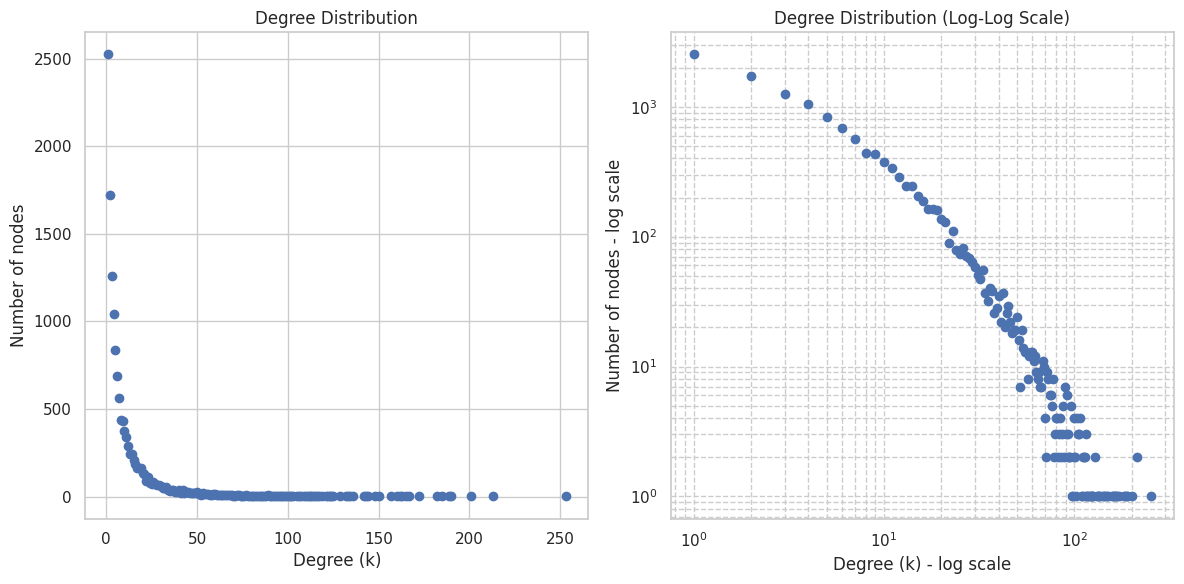

In [8]:
# Calculate the degree distribution
degrees = [G.degree(n) for n in G.nodes()]
degree_counts = Counter(degrees)

# Create a dataframe for easier analysis
degree_df = pd.DataFrame.from_dict(degree_counts, orient='index').reset_index()
degree_df.columns = ['Degree', 'Count']
degree_df = degree_df.sort_values('Degree')

# Calculate degree statistics
avg_degree = np.mean(degrees)
median_degree = np.median(degrees)
max_degree = np.max(degrees)
min_degree = np.min(degrees)

print(f"Average degree: {avg_degree:.2f}")
print(f"Median degree: {median_degree:.0f}")
print(f"Maximum degree: {max_degree}")
print(f"Minimum degree: {min_degree}")

# Plot the degree distribution
plt.figure(figsize=(12, 6))

# Regular plot
plt.subplot(121)
plt.scatter(degree_df['Degree'], degree_df['Count'])
plt.xlabel('Degree (k)')
plt.ylabel('Number of nodes')
plt.title('Degree Distribution')
plt.grid(True)

# Log-log plot to check for power law
plt.subplot(122)
plt.loglog(degree_df['Degree'], degree_df['Count'], 'o')
plt.xlabel('Degree (k) - log scale')
plt.ylabel('Number of nodes - log scale')
plt.title('Degree Distribution (Log-Log Scale)')
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

## Path Length Analysis

Average shortest path length: 5.4492
Network diameter: 18


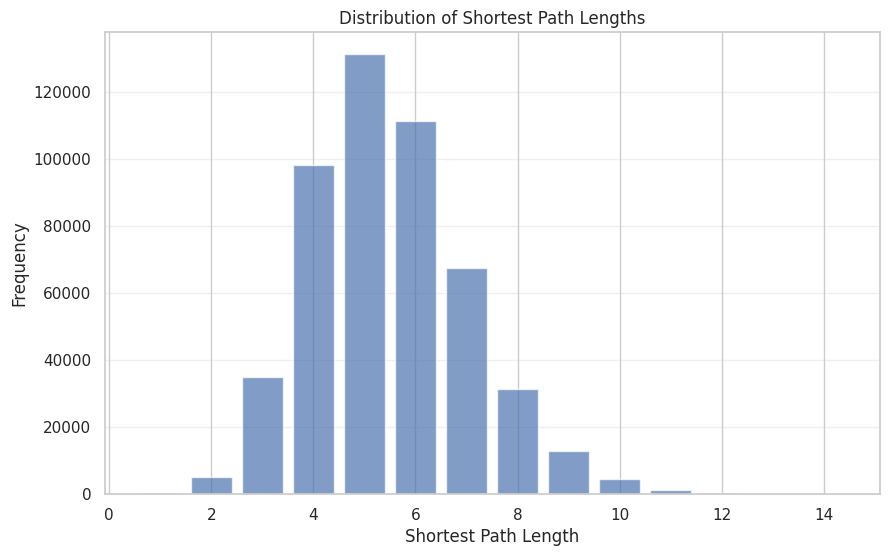

In [13]:
# Calculate the average shortest path length
# Note: We'll use the largest connected component as the full graph might have disconnected parts
avg_shortest_path = nx.average_shortest_path_length(G_lcc)
print(f"Average shortest path length: {avg_shortest_path:.4f}")

# Calculate the diameter (maximum shortest path length)
diameter = nx.diameter(G_lcc)
print(f"Network diameter: {diameter}")

# Calculate the distribution of path lengths
# For large graphs, we'll use a sample of node pairs to estimate
import random
sample_size = min(1000, G_lcc.number_of_nodes())
nodes = list(G_lcc.nodes())
sample_nodes = random.sample(nodes, sample_size)

path_lengths = []
for i in range(sample_size-1):
    for j in range(i+1, sample_size):
        source = sample_nodes[i]
        target = sample_nodes[j]
        path_length = nx.shortest_path_length(G_lcc, source=source, target=target)
        path_lengths.append(path_length)

# Plot the distribution of path lengths
path_counts = Counter(path_lengths)
path_df = pd.DataFrame.from_dict(path_counts, orient='index').reset_index()
path_df.columns = ['Path Length', 'Count']
path_df = path_df.sort_values('Path Length')

plt.figure(figsize=(10, 6))
plt.bar(path_df['Path Length'], path_df['Count'], alpha=0.7)
plt.xlabel('Shortest Path Length')
plt.ylabel('Frequency')
plt.title('Distribution of Shortest Path Lengths')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## Clustering Analysis

Global clustering coefficient (transitivity): 0.1664
Average local clustering coefficient: 0.1714


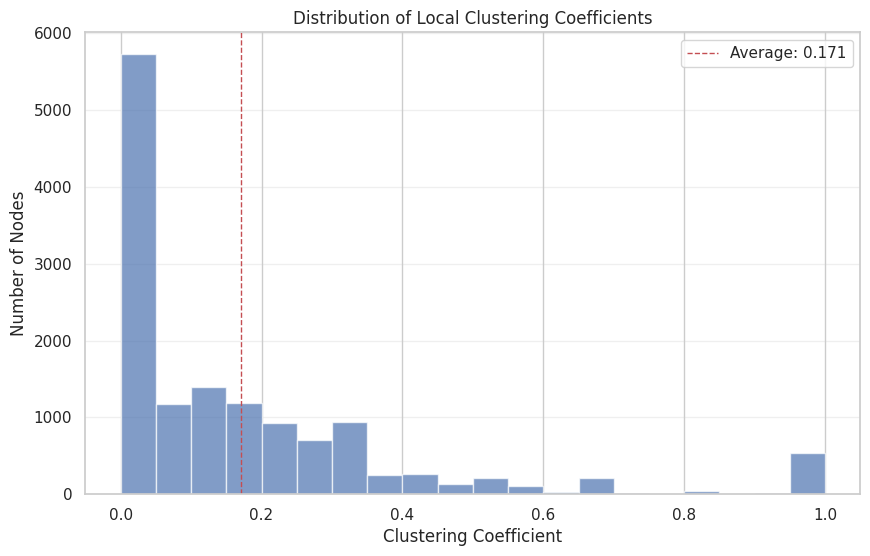

In [14]:
# Calculate the global clustering coefficient (transitivity)
global_clustering = nx.transitivity(G)
print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")

# Calculate the average local clustering coefficient
avg_local_clustering = nx.average_clustering(G)
print(f"Average local clustering coefficient: {avg_local_clustering:.4f}")

# Calculate local clustering coefficients for each node
clustering_coeffs = nx.clustering(G)

# Create a dataframe for analysis
clustering_df = pd.DataFrame.from_dict(clustering_coeffs, orient='index').reset_index()
clustering_df.columns = ['Node', 'Clustering Coefficient']

# Plot histogram of clustering coefficients
plt.figure(figsize=(10, 6))
plt.hist(clustering_df['Clustering Coefficient'], bins=20, alpha=0.7)
plt.xlabel('Clustering Coefficient')
plt.ylabel('Number of Nodes')
plt.title('Distribution of Local Clustering Coefficients')
plt.grid(True, axis='y', alpha=0.3)
plt.axvline(avg_local_clustering, color='r', linestyle='dashed', linewidth=1, 
            label=f'Average: {avg_local_clustering:.3f}')
plt.legend()
plt.show()

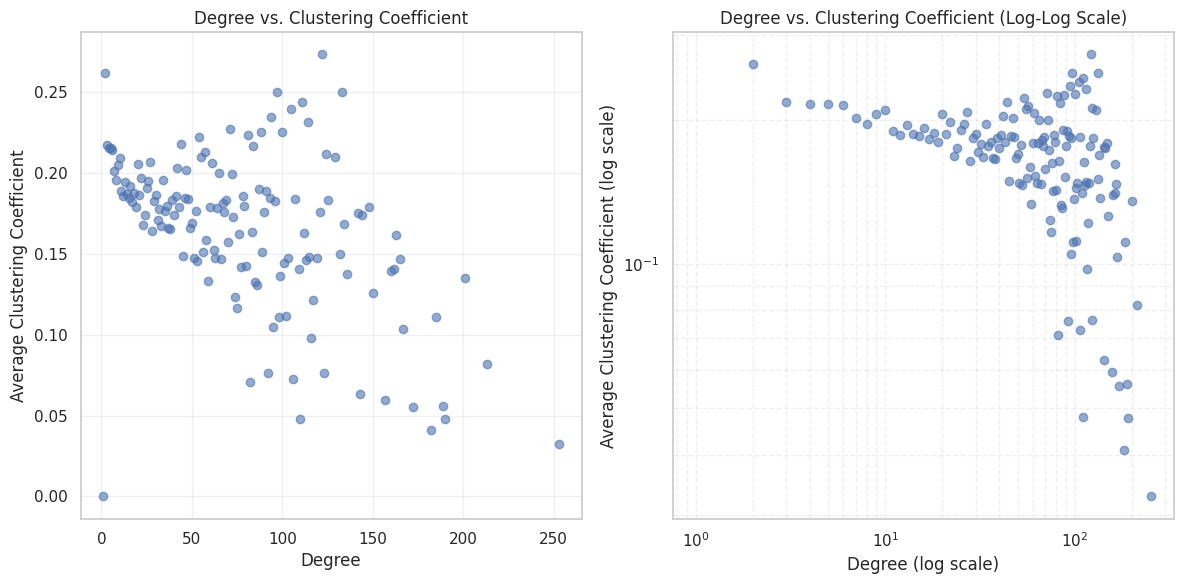

In [15]:
# Analyze the relationship between degree and clustering coefficient
degree_clustering = {}
for node in G.nodes():
    degree = G.degree(node)
    clustering = clustering_coeffs[node]
    if degree in degree_clustering:
        degree_clustering[degree].append(clustering)
    else:
        degree_clustering[degree] = [clustering]

# Calculate average clustering coefficient for each degree
avg_clustering_by_degree = {k: np.mean(v) for k, v in degree_clustering.items()}

# Convert to dataframe
dc_df = pd.DataFrame(list(avg_clustering_by_degree.items()), columns=['Degree', 'Avg Clustering'])
dc_df = dc_df.sort_values('Degree')

# Plot degree vs clustering coefficient
plt.figure(figsize=(12, 6))

# Regular plot
plt.subplot(121)
plt.scatter(dc_df['Degree'], dc_df['Avg Clustering'], alpha=0.6)
plt.xlabel('Degree')
plt.ylabel('Average Clustering Coefficient')
plt.title('Degree vs. Clustering Coefficient')
plt.grid(True, alpha=0.3)

# Log-log plot
plt.subplot(122)
plt.loglog(dc_df['Degree'], dc_df['Avg Clustering'], 'o', alpha=0.6)
plt.xlabel('Degree (log scale)')
plt.ylabel('Average Clustering Coefficient (log scale)')
plt.title('Degree vs. Clustering Coefficient (Log-Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Centrality Analysis

In [22]:
# For large networks, computing centrality measures can be time-consuming
# We'll work with the largest connected component for this analysis

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G_lcc)

# Calculate betweenness centrality (this might take some time)
print("Computing betweenness centrality (this might take a while)...")
# Use approximate betweenness with sampling for large networks
k = min(1000, G_lcc.number_of_nodes())  # Number of sample nodes
betweenness_centrality = nx.betweenness_centrality(G_lcc, k=k, normalized=True, seed=42)

# Calculate closeness centrality
print("Computing closeness centrality...")
closeness_centrality = nx.closeness_centrality(G_lcc)

# Create a dataframe with centrality measures
centrality_df = pd.DataFrame({
    'Node': list(G_lcc.nodes()),
    'Degree Centrality': [degree_centrality[n] for n in G_lcc.nodes()],
    'Betweenness Centrality': [betweenness_centrality[n] for n in G_lcc.nodes()],
    'Closeness Centrality': [closeness_centrality[n] for n in G_lcc.nodes()]
})

# Display top 20 nodes by different centrality measures
print("\nTop 20 nodes by Degree Centrality:")
display(centrality_df.sort_values('Degree Centrality', ascending=False).head(20))

print("\nTop 20 nodes by Betweenness Centrality:")
display(centrality_df.sort_values('Betweenness Centrality', ascending=False).head(20))

print("\nTop 20 nodes by Closeness Centrality:")
display(centrality_df.sort_values('Closeness Centrality', ascending=False).head(20))

Computing betweenness centrality (this might take a while)...
Computing closeness centrality...

Top 20 nodes by Degree Centrality:


,Node,Degree Centrality,Betweenness Centrality,Closeness Centrality
272,6cEuCEZu7PAE9ZSzLLc2oQ,0.018812,0.055025,0.293390
924,7hJcb9fa4alzcOq3EaNPoG,0.015838,0.067542,0.294173
259,7c0XG5cIJTrrAgEC3ULPiq,0.015838,0.007166,0.281042
17,329e4yvIujISKGKz1BZZbO,0.014945,0.018475,0.277316
160,77AiFEVeAVj2ORpC85QVJs,0.014127,0.015065,0.282127
329,1Cs0zKBU1kc0i8ypK3B9ai,0.014053,0.018180,0.287581
390,6vXTefBL93Dj5IqAWq6OTv,0.013756,0.015246,0.285881
734,5fMUXHkw8R8eOP2RNVYEZX,0.013533,0.027047,0.285233
341,2o5jDhtHVPhrJdv3cEQ99Z,0.012789,0.017132,0.283167
97,1vyhD5VmyZ7KMfW5gqLgo5,0.012417,0.015771,0.283632



Top 20 nodes by Betweenness Centrality:


,Node,Degree Centrality,Betweenness Centrality,Closeness Centrality
924,7hJcb9fa4alzcOq3EaNPoG,0.015838,0.067542,0.294173
272,6cEuCEZu7PAE9ZSzLLc2oQ,0.018812,0.055025,0.293390
734,5fMUXHkw8R8eOP2RNVYEZX,0.013533,0.027047,0.285233
2474,7DdW8Ert3Z36hb1FkaZWiI,0.002751,0.023251,0.233668
162,738wLrAtLtCtFOLvQBXOXp,0.010633,0.019065,0.282833
1676,6eUKZXaKkcviH0Ku9w2n3V,0.008551,0.018926,0.277408
17,329e4yvIujISKGKz1BZZbO,0.014945,0.018475,0.277316
329,1Cs0zKBU1kc0i8ypK3B9ai,0.014053,0.018180,0.287581
1683,5LHRHt1k9lMyONurDHEdrp,0.010112,0.017918,0.282062
880,0NbfKEOTQCcwd6o7wSDOHI,0.008997,0.017671,0.275934



Top 20 nodes by Closeness Centrality:


,Node,Degree Centrality,Betweenness Centrality,Closeness Centrality
924,7hJcb9fa4alzcOq3EaNPoG,0.015838,0.067542,0.294173
272,6cEuCEZu7PAE9ZSzLLc2oQ,0.018812,0.055025,0.293390
329,1Cs0zKBU1kc0i8ypK3B9ai,0.014053,0.018180,0.287581
390,6vXTefBL93Dj5IqAWq6OTv,0.013756,0.015246,0.285881
734,5fMUXHkw8R8eOP2RNVYEZX,0.013533,0.027047,0.285233
1916,3Isy6kedDrgPYoTS1dazA9,0.009146,0.011988,0.284256
97,1vyhD5VmyZ7KMfW5gqLgo5,0.012417,0.015771,0.283632
341,2o5jDhtHVPhrJdv3cEQ99Z,0.012789,0.017132,0.283167
162,738wLrAtLtCtFOLvQBXOXp,0.010633,0.019065,0.282833
435,0TnOYISbd1XYRBk9myaseg,0.011674,0.014965,0.282133


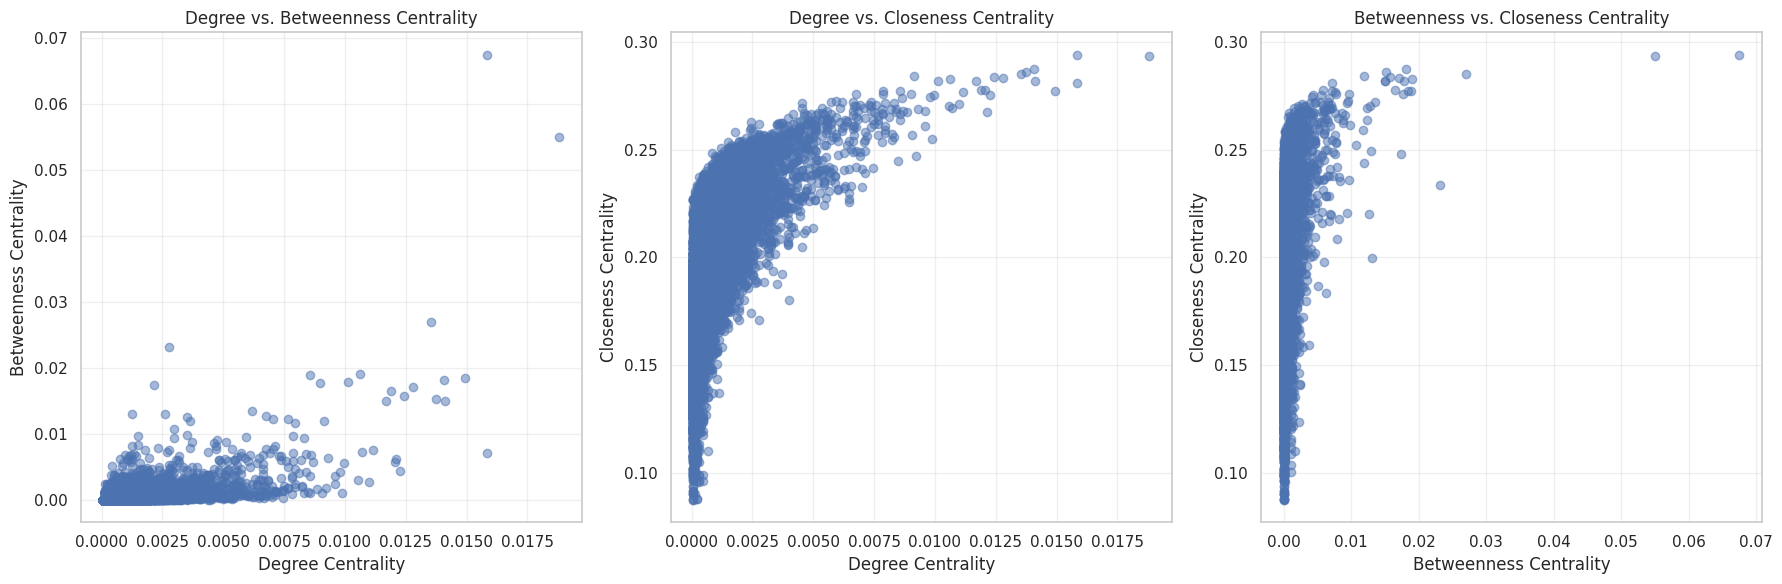

In [17]:
# Compare the different centrality measures
plt.figure(figsize=(18, 6))

# Degree vs Betweenness
plt.subplot(131)
plt.scatter(centrality_df['Degree Centrality'], centrality_df['Betweenness Centrality'], alpha=0.5)
plt.xlabel('Degree Centrality')
plt.ylabel('Betweenness Centrality')
plt.title('Degree vs. Betweenness Centrality')
plt.grid(True, alpha=0.3)

# Degree vs Closeness
plt.subplot(132)
plt.scatter(centrality_df['Degree Centrality'], centrality_df['Closeness Centrality'], alpha=0.5)
plt.xlabel('Degree Centrality')
plt.ylabel('Closeness Centrality')
plt.title('Degree vs. Closeness Centrality')
plt.grid(True, alpha=0.3)

# Betweenness vs Closeness
plt.subplot(133)
plt.scatter(centrality_df['Betweenness Centrality'], centrality_df['Closeness Centrality'], alpha=0.5)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Closeness Centrality')
plt.title('Betweenness vs. Closeness Centrality')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Community Detection

https://python-louvain.readthedocs.io/en/latest/api.html

https://en.wikipedia.org/wiki/Louvain_method

Detecting communities using Louvain algorithm...
Number of communities detected: 34

Top 10 communities by size:


,Community,Size
3,3,1732
2,2,1611
9,9,1160
12,12,883
6,6,658
14,14,563
1,1,535
5,5,471
17,17,433
20,20,403


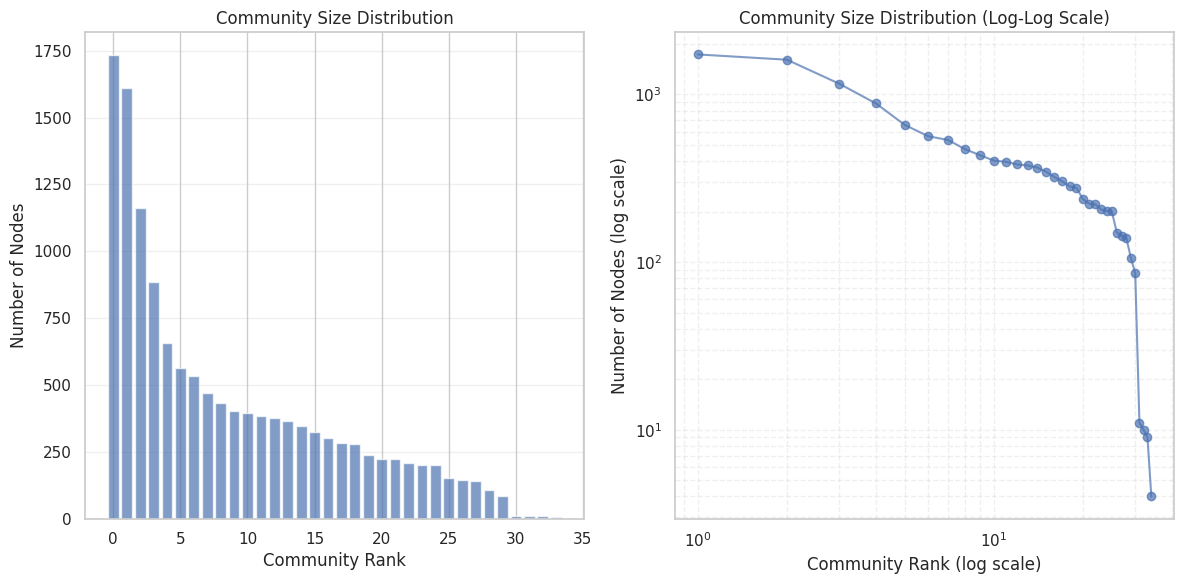

In [9]:
# Community detection using the Louvain algorithm
import community as community_louvain

# Apply the Louvain algorithm
print("Detecting communities using Louvain algorithm...")
partition = community_louvain.best_partition(G_lcc)

# Get the set of communities
communities = set(partition.values())
print(f"Number of communities detected: {len(communities)}")

# Count nodes in each community
community_sizes = Counter(partition.values())
sizes_df = pd.DataFrame.from_dict(community_sizes, orient='index').reset_index()
sizes_df.columns = ['Community', 'Size']
sizes_df = sizes_df.sort_values('Size', ascending=False)

print("\nTop 10 communities by size:")
display(sizes_df.head(10))

# Plot community size distribution
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.bar(range(len(sizes_df)), sizes_df['Size'], alpha=0.7)
plt.xlabel('Community Rank')
plt.ylabel('Number of Nodes')
plt.title('Community Size Distribution')
plt.grid(True, axis='y', alpha=0.3)

plt.subplot(122)
plt.loglog(range(1, len(sizes_df) + 1), sizes_df['Size'], 'o-', alpha=0.7)
plt.xlabel('Community Rank (log scale)')
plt.ylabel('Number of Nodes (log scale)')
plt.title('Community Size Distribution (Log-Log Scale)')
plt.grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
selected_nodes['Community'] = selected_nodes['spotify_id'].map(partition)

In [23]:
selected_nodes.query('Community == 3').sort_values('followers', ascending=False).head(10)

,spotify_id,name,followers,popularity,genres,chart_hits,Community
17512,3Nrfpe0tUJi4K4DXYWgMUX,BTS,54532917.0,91,"[k-pop, k-pop boy group]","['us (55)', 'gb (32)', 'ar (30)', 'au (32)', 'at (30)', 'be (17)', 'bo (54)', 'br (31)', 'bg (77)', 'ca (49)', 'cl (32)', 'co (35)', 'cr (34)', 'cy (34)', 'cz (22)', 'dk (13)', 'do (30)', 'ec (34)...",3.0
18098,4dpARuHxo51G3z768sgnrY,Adele,42174621.0,84,"[british soul, pop, uk pop]","['us (24)', 'gb (29)', 'ar (8)', 'au (25)', 'at (22)', 'be (27)', 'bo (8)', 'br (13)', 'bg (20)', 'ca (23)', 'cl (9)', 'co (16)', 'cr (23)', 'cy (23)', 'cz (22)', 'dk (23)', 'do (21)', 'ec (9)', '...",3.0
7165,53XhwfbYqKCa1cC15pYq2q,Imagine Dragons,41751320.0,88,"[modern rock, rock]","['us (29)', 'gb (25)', 'ar (14)', 'au (18)', 'at (29)', 'be (24)', 'bo (18)', 'br (23)', 'bg (30)', 'ca (30)', 'cl (13)', 'co (15)', 'cr (18)', 'cy (17)', 'cz (53)', 'dk (19)', 'do (13)', 'ec (14)...",3.0
19326,7n2wHs1TKAczGzO7Dd2rGr,Shawn Mendes,39186962.0,84,"[canadian pop, dance pop, pop, viral pop]","['us (33)', 'gb (30)', 'ar (14)', 'au (31)', 'at (39)', 'be (39)', 'bo (15)', 'br (19)', 'bg (39)', 'ca (45)', 'cl (14)', 'co (14)', 'cr (18)', 'cy (31)', 'cz (35)', 'dk (37)', 'do (15)', 'ec (14)...",3.0
7515,4gzpq5DPGxSnKTe4SA8HAU,Coldplay,38371125.0,88,"[permanent wave, pop]","['us (18)', 'gb (29)', 'ar (18)', 'au (16)', 'at (17)', 'be (23)', 'bo (11)', 'br (17)', 'bg (14)', 'ca (20)', 'cl (18)', 'co (13)', 'cr (32)', 'cy (12)', 'cz (23)', 'dk (17)', 'do (15)', 'ec (10)...",3.0
8272,0C8ZW7ezQVs4URX5aX7Kqx,Selena Gomez,37269207.0,82,"[dance pop, pop, post-teen pop, uk pop]","['us (31)', 'gb (16)', 'ar (17)', 'au (16)', 'at (15)', 'be (21)', 'bo (17)', 'br (26)', 'bg (33)', 'ca (28)', 'cl (17)', 'co (18)', 'cr (18)', 'cy (24)', 'cz (20)', 'dk (17)', 'do (20)', 'ec (17)...",3.0
23,6M2wZ9GZgrQXHCFfjv46we,Dua Lipa,36163788.0,88,"[dance pop, pop, uk pop]","['us (17)', 'gb (25)', 'ar (18)', 'au (20)', 'at (14)', 'be (23)', 'bo (10)', 'br (18)', 'bg (24)', 'ca (19)', 'cl (16)', 'co (18)', 'cr (18)', 'cy (21)', 'cz (17)', 'dk (17)', 'do (9)', 'ec (9)',...",3.0
15787,7vk5e3vY1uw9plTHJAMwjN,Alan Walker,35053203.0,80,[electro house],"['us (4)', 'gb (4)', 'ar (2)', 'au (6)', 'at (16)', 'be (9)', 'bo (4)', 'br (2)', 'bg (9)', 'ca (9)', 'cl (3)', 'co (3)', 'cr (3)', 'cy (8)', 'cz (12)', 'dk (12)', 'do (3)', 'ec (3)', 'eg (9)', 's...",3.0
18045,64KEffDW9EtZ1y2vBYgq8T,Marshmello,34229273.0,83,"[dance pop, edm, pop, pop dance, progressive electro house]","['us (18)', 'gb (14)', 'ar (3)', 'au (13)', 'at (13)', 'be (15)', 'bo (5)', 'br (6)', 'bg (14)', 'ca (19)', 'cl (3)', 'co (3)', 'cr (5)', 'cy (17)', 'cz (17)', 'dk (13)', 'do (6)', 'ec (4)', 'eg (...",3.0
9488,41MozSoPIsD1dJM0CLPjZF,BLACKPINK,32382333.0,87,"[k-pop, k-pop girl group]","['us (11)', 'gb (8)', 'ar (10)', 'au (13)', 'at (7)', 'be (6)', 'bo (9)', 'br (12)', 'bg (18)', 'ca (14)', 'cl (11)', 'co (11)', 'cr (11)', 'cy (10)', 'cz (7)', 'dk (5)', 'do (10)', 'ec (9)', 'eg ...",3.0


In [21]:
selected_nodes.query('Community == 2').sort_values('followers', ascending=False).head(5)

,spotify_id,name,followers,popularity,genres,chart_hits,Community
11181,4q3ewBCX7sLwd24euuV69X,Bad Bunny,55669387.0,100,"[reggaeton, trap latino]","['us (76)', 'gb (1)', 'ar (91)', 'au (2)', 'at (5)', 'be (9)', 'bo (97)', 'br (1)', 'bg (5)', 'ca (15)', 'cl (106)', 'co (98)', 'cr (96)', 'cy (11)', 'cz (2)', 'dk (4)', 'do (110)', 'ec (97)', 'eg...",2.0
18372,1vyhD5VmyZ7KMfW5gqLgo5,J Balvin,35224872.0,88,"[reggaeton, reggaeton colombiano, trap latino]","['us (21)', 'gb (3)', 'ar (48)', 'au (3)', 'at (8)', 'be (10)', 'bo (52)', 'br (7)', 'bg (14)', 'ca (12)', 'cl (57)', 'co (87)', 'cr (57)', 'cy (11)', 'cz (6)', 'dk (4)', 'do (67)', 'ec (62)', 'eg...",2.0
5006,1i8SpTcr7yvPOmcqrbnVXY,Ozuna,33511653.0,86,"[reggaeton, trap latino]","['us (10)', 'ar (60)', 'at (1)', 'be (2)', 'bo (48)', 'br (1)', 'bg (2)', 'ca (4)', 'cl (76)', 'co (63)', 'cr (57)', 'cy (3)', 'cz (1)', 'do (110)', 'ec (52)', 'sv (55)', 'ee (2)', 'fr (2)', 'de (...",2.0
13348,1r4hJ1h58CWwUQe3MxPuau,Maluma,32165351.0,84,"[reggaeton, reggaeton colombiano, trap latino]","['us (5)', 'gb (1)', 'ar (43)', 'au (1)', 'at (4)', 'be (5)', 'bo (59)', 'br (4)', 'bg (12)', 'ca (4)', 'cl (43)', 'co (67)', 'cr (35)', 'cy (4)', 'cz (2)', 'dk (1)', 'do (35)', 'ec (58)', 'eg (1)...",2.0
1150,4VMYDCV2IEDYJArk749S6m,Daddy Yankee,29446452.0,87,"[latin hip hop, reggaeton, trap latino]","['us (3)', 'gb (1)', 'ar (32)', 'au (1)', 'at (3)', 'be (2)', 'bo (35)', 'br (1)', 'bg (4)', 'ca (4)', 'cl (51)', 'co (34)', 'cr (31)', 'cy (4)', 'cz (2)', 'dk (1)', 'do (42)', 'ec (47)', 'eg (1)'...",2.0


In [24]:
selected_nodes.query('Community == 9').sort_values('followers', ascending=False).head(10)

,spotify_id,name,followers,popularity,genres,chart_hits,Community
14169,6eUKZXaKkcviH0Ku9w2n3V,Ed Sheeran,102156853.0,90,"[pop, uk pop]","['us (52)', 'gb (83)', 'ar (36)', 'au (65)', 'at (59)', 'be (58)', 'bo (29)', 'br (43)', 'bg (60)', 'ca (63)', 'cl (33)', 'co (31)', 'cr (40)', 'cy (44)', 'cz (65)', 'dk (71)', 'do (30)', 'ec (28)...",9.0
17566,66CXWjxzNUsdJxJ2JdwvnR,Ariana Grande,83045090.0,88,"[dance pop, pop]","['us (81)', 'gb (69)', 'ar (36)', 'au (70)', 'at (43)', 'be (61)', 'bo (25)', 'br (57)', 'bg (77)', 'ca (80)', 'cl (29)', 'co (34)', 'cr (53)', 'cy (57)', 'cz (41)', 'dk (44)', 'do (51)', 'ec (25)...",9.0
18149,6qqNVTkY8uBg9cP3Jd7DAH,Billie Eilish,68407227.0,88,"[art pop, electropop, pop]","['us (46)', 'gb (43)', 'ar (23)', 'au (45)', 'at (42)', 'be (43)', 'bo (18)', 'br (23)', 'bg (45)', 'ca (44)', 'cl (17)', 'co (19)', 'cr (26)', 'cy (44)', 'cz (35)', 'dk (42)', 'do (25)', 'ec (18)...",9.0
18687,3TVXtAsR1Inumwj472S9r4,Drake,66852536.0,95,"[canadian hip hop, canadian pop, hip hop, rap]","['us (190)', 'gb (163)', 'ar (18)', 'au (148)', 'at (97)', 'be (99)', 'bo (22)', 'br (31)', 'bg (125)', 'ca (179)', 'cl (20)', 'co (24)', 'cr (52)', 'cy (105)', 'cz (55)', 'dk (132)', 'do (116)', ...",9.0
6227,1uNFoZAHBGtllmzznpCI3s,Justin Bieber,65590075.0,90,"[canadian pop, pop]","['us (58)', 'gb (51)', 'ar (29)', 'au (54)', 'at (44)', 'be (46)', 'bo (23)', 'br (32)', 'bg (40)', 'ca (62)', 'cl (25)', 'co (25)', 'cr (27)', 'cy (31)', 'cz (39)', 'dk (66)', 'do (32)', 'ec (26)...",9.0
5477,7dGJo4pcD2V6oG8kP0tJRR,Eminem,59184634.0,90,"[hip hop, rap]","['us (78)', 'gb (72)', 'ar (7)', 'au (64)', 'at (61)', 'be (48)', 'bo (8)', 'br (10)', 'bg (73)', 'ca (73)', 'cl (5)', 'co (7)', 'cr (15)', 'cy (62)', 'cz (54)', 'dk (54)', 'do (12)', 'ec (8)', 'e...",9.0
4638,06HL4z0CvFAxyc27GXpf02,Taylor Swift,58554324.0,94,[pop],"['us (136)', 'gb (115)', 'ar (24)', 'au (110)', 'at (36)', 'be (54)', 'bo (12)', 'br (40)', 'bg (49)', 'ca (121)', 'cl (11)', 'co (16)', 'cr (28)', 'cy (43)', 'cz (28)', 'dk (39)', 'do (14)', 'ec ...",9.0
15077,5pKCCKE2ajJHZ9KAiaK11H,Rihanna,50002769.0,87,"[dance pop, pop, urban contemporary]","['us (19)', 'gb (17)', 'ar (6)', 'au (12)', 'at (10)', 'be (10)', 'bo (6)', 'br (24)', 'bg (19)', 'ca (22)', 'cl (8)', 'co (7)', 'cr (7)', 'cy (7)', 'cz (9)', 'dk (16)', 'do (8)', 'ec (6)', 'sv (6...",9.0
13850,1Xyo4u8uXC1ZmMpatF05PJ,The Weeknd,49387909.0,93,"[canadian pop, pop]","['us (81)', 'gb (74)', 'ar (23)', 'au (76)', 'at (61)', 'be (68)', 'bo (46)', 'br (41)', 'bg (83)', 'ca (83)', 'cl (29)', 'co (39)', 'cr (46)', 'cy (62)', 'cz (65)', 'dk (76)', 'do (62)', 'ec (36)...",9.0
12282,0du5cEVh5yTK9QJze8zA0C,Bruno Mars,43103624.0,87,"[dance pop, pop]","['us (24)', 'gb (19)', 'ar (12)', 'au (17)', 'at (11)', 'be (15)', 'bo (10)', 'br (12)', 'bg (8)', 'ca (25)', 'cl (15)', 'co (11)', 'cr (21)', 'cy (8)', 'cz (10)', 'dk (19)', 'do (19)', 'ec (12)',...",9.0


In [25]:
selected_nodes.query('Community == 12').sort_values('followers', ascending=False).head(10)

,spotify_id,name,followers,popularity,genres,chart_hits,Community
9317,0L5fC7Ogm2YwgqVCRcF1bT,Volbeat,2182472.0,70,[alternative metal],"['at (3)', 'dk (11)', 'fi (10)', 'de (3)', 'no (4)', 'se (9)']",12.0
3783,25u4wHJWxCA9vO0CzxAbK7,Lukas Graham,1966327.0,71,"[danish pop, pop, scandipop]","['us (2)', 'gb (3)', 'ar (1)', 'au (3)', 'at (4)', 'be (3)', 'bo (2)', 'br (2)', 'bg (3)', 'ca (3)', 'cl (2)', 'co (1)', 'cr (2)', 'cy (3)', 'cz (3)', 'dk (41)', 'do (1)', 'ec (2)', 'sv (2)', 'ee ...",12.0
7943,7w29UYBi0qsHi5RTcv3lmA,Björk,1648455.0,66,"[art pop, electronica, icelandic pop, metropopolis, permanent wave]",['tw (1)'],12.0
11862,3Fw8q9sZ1t7diLxoQFS8hW,Hanin Dhiya,1284402.0,53,[indonesian pop],"['id (7)', 'my (1)']",12.0
14874,21egYD1eInY6bGFcniCRT1,First Aid Kit,1092629.0,62,[stomp and holler],"['au (1)', 'be (1)', 'ee (1)', 'ie (1)', 'nl (1)', 'no (1)', 'se (16)', 'tr (1)']",12.0
17030,2OIWxN9xUhgUHkeUCWCaNs,Veronica Maggio,525086.0,62,[swedish pop],"['lu (1)', 'no (3)', 'se (54)']",12.0
8410,0yqCOSZ1i0c49UUbE8AzbQ,Rasmus Seebach,465433.0,58,"[classic danish pop, danish pop]",['dk (50)'],12.0
15334,4KXp3xtaz1wWXnu5u34eVX,kent,457646.0,56,"[classic swedish pop, swedish pop]","['fi (1)', 'se (34)']",12.0
19218,4bOG1sx3QHFbOUVLNmMpPe,Timbuktu,448103.0,50,"[swedish hip hop, swedish pop, swedish pop rap]",['se (4)'],12.0
12220,4sj6D0zlMOl25nprDJBiU9,Andy Williams,443747.0,57,"[adult standards, brill building pop, lounge, mellow gold]","['us (4)', 'gb (1)', 'au (1)', 'at (1)', 'be (2)', 'bg (1)', 'ca (4)', 'cr (1)', 'cy (1)', 'cz (2)', 'dk (1)', 'ec (1)', 'ee (2)', 'fi (1)', 'fr (1)', 'de (1)', 'gr (2)', 'gt (1)', 'hn (1)', 'hk (...",12.0


In [26]:
selected_nodes.query('Community == 6').sort_values('followers', ascending=False).head(10)

,spotify_id,name,followers,popularity,genres,chart_hits,Community
11537,1yR65psqiazQpeM79CcGh8,Marília Mendonça,26420724.0,83,"[arrocha, sertanejo]","['br (82)', 'py (3)', 'pt (24)']",6.0
7311,1elUiq4X7pxej6FRlrEzjM,Jorge & Mateus,17262357.0,81,"[arrocha, sertanejo, sertanejo universitario]","['br (74)', 'py (1)', 'pt (4)']",6.0
763,7MiDcPa6UiV3In7lIM71IN,Gusttavo Lima,17171304.0,80,"[arrocha, sertanejo, sertanejo universitario]","['br (55)', 'py (2)', 'pt (5)']",6.0
17698,487N2T9nIPEHrlTZLL3SQs,Zé Neto & Cristiano,17107399.0,73,"[arrocha, sertanejo, sertanejo pop, sertanejo universitario]","['br (50)', 'py (7)', 'pt (3)']",6.0
2167,3p7PcrEHaaKLJnPUGOtRlT,Henrique & Juliano,16541414.0,81,"[arrocha, sertanejo universitario]","['br (87)', 'py (5)', 'pt (2)']",6.0
7591,7FNnA9vBm6EKceENgCGRMb,Anitta,12159259.0,81,"[funk carioca, pop nacional]","['us (3)', 'ar (9)', 'at (1)', 'be (2)', 'bo (12)', 'br (54)', 'bg (3)', 'ca (3)', 'cl (9)', 'co (8)', 'cr (5)', 'cy (3)', 'cz (1)', 'do (6)', 'ec (10)', 'sv (5)', 'ee (2)', 'fr (1)', 'de (2)', 'g...",6.0
14023,59jlthNnbmim5l9tmNA7se,Maiara & Maraisa,11280023.0,77,"[sertanejo, sertanejo pop, sertanejo universitario]",['br (27)'],6.0
19284,1AL2GKpmRrKXkYIcASuRFa,Wesley Safadão,11101764.0,74,"[arrocha, forro, sertanejo pop]","['br (45)', 'py (1)', 'pt (2)']",6.0
5072,2Z0lRIqr997lIUiPtrpKCr,Matheus & Kauan,10227915.0,76,"[arrocha, pop nacional, sertanejo pop, sertanejo universitario]","['br (53)', 'py (1)', 'pt (2)']",6.0
2165,0vLuOi2k62sHujIfplInlK,Hungria Hip Hop,8023384.0,70,"[brazilian hip hop, trap brasileiro]",['br (12)'],6.0


In [27]:
selected_nodes.query('Community == 14').sort_values('followers', ascending=False).head(10)

,spotify_id,name,followers,popularity,genres,chart_hits,Community
18262,6Te49r3A6f5BiIgBRxH7FH,Ninho,6858658.0,79,"[french hip hop, pop urbaine]","['be (78)', 'fr (104)', 'lu (66)', 'ma (35)', 'ch (72)']",14.0
14217,3IW7ScrzXmPvZhB27hmfgy,Jul,5947411.0,79,"[francoton, rap marseille]","['at (1)', 'be (20)', 'fr (379)', 'de (1)', 'lu (5)', 'ma (14)', 'nl (1)', 'es (1)', 'ch (15)']",14.0
17056,3NH8t45zOTqzlZgBvZRjvB,PNL,5720547.0,74,"[french hip hop, pop urbaine]","['be (35)', 'ca (1)', 'fr (59)', 'lu (35)', 'ma (24)', 'nl (1)', 'ch (37)']",14.0
6578,5abSRg0xN1NV3gLbuvX24M,Amr Diab,4653784.0,55,"[arab pop, egyptian pop, rif]",['eg (59)'],14.0
7594,7CUFPNi1TU8RowpnFRSsZV,Niska,4437109.0,73,"[french hip hop, pop urbaine]","['at (1)', 'be (50)', 'fr (90)', 'de (1)', 'lu (48)', 'ma (22)', 'ch (49)']",14.0
15541,4sbXXFzEWJY2zsZjelerjX,Dadju,4386145.0,72,"[francoton, french hip hop, pop urbaine]","['be (25)', 'fr (54)', 'lu (18)', 'ma (9)', 'pt (1)', 'ch (20)']",14.0
6757,2UwqpfQtNuhBwviIC0f2ie,Damso,3860495.0,75,"[belgian hip hop, french hip hop, pop urbaine, rap conscient]","['be (73)', 'fr (80)', 'lu (61)', 'ma (28)', 'ch (64)']",14.0
17500,0GgY7hjMoGDsX8ZDe2mwds,Soolking,3600970.0,73,"[francoton, french hip hop, pop urbaine]","['at (4)', 'be (11)', 'dk (1)', 'fr (35)', 'de (5)', 'it (1)', 'lu (6)', 'ma (42)', 'nl (1)', 'ro (1)', 'ch (7)']",14.0
1279,7IlRNXHjoOCgEAWN5qYksg,Aya Nakamura,3559233.0,68,"[basshall, francoton, pop urbaine]","['ar (1)', 'at (3)', 'be (25)', 'bo (2)', 'bg (1)', 'cl (2)', 'co (2)', 'cr (2)', 'cy (2)', 'do (1)', 'ec (2)', 'sv (2)', 'fr (42)', 'de (3)', 'gr (1)', 'gt (2)', 'hn (2)', 'hu (1)', 'in (1)', 'id...",14.0
10572,0GOx72r5AAEKRGQFn3xqXK,GIMS,3557401.0,69,"[francoton, french hip hop, rap conscient]","['at (3)', 'be (15)', 'bg (3)', 'cy (1)', 'cz (1)', 'dk (3)', 'ec (1)', 'fr (97)', 'de (4)', 'gr (2)', 'hu (2)', 'il (1)', 'it (1)', 'lu (14)', 'ma (3)', 'nl (3)', 'no (1)', 'pt (1)', 'ro (2)', 's...",14.0


## Small World Properties

In [19]:
# Test for small-world properties
# A network is a small-world network if:
# 1. It has a similar average path length to an equivalent random graph
# 2. It has a much higher clustering coefficient than an equivalent random graph

# Create a random graph with the same number of nodes and average degree
n = G_lcc.number_of_nodes()
m = G_lcc.number_of_edges()
p = 2 * m / (n * (n - 1))  # Probability of edge existence
random_G = nx.erdos_renyi_graph(n, p, seed=42)

# Calculate clustering coefficients
clustering_actual = nx.average_clustering(G_lcc)
clustering_random = nx.average_clustering(random_G)

# Calculate average path lengths
path_length_actual = nx.average_shortest_path_length(G_lcc)
path_length_random = nx.average_shortest_path_length(random_G)

print(f"Actual Network - Average Clustering: {clustering_actual:.4f}")
print(f"Random Network - Average Clustering: {clustering_random:.4f}")
print(f"Clustering Ratio (Actual/Random): {clustering_actual/clustering_random:.2f}x")

print(f"\nActual Network - Average Path Length: {path_length_actual:.4f}")
print(f"Random Network - Average Path Length: {path_length_random:.4f}")
print(f"Path Length Ratio (Actual/Random): {path_length_actual/path_length_random:.2f}x")

# Check sigma for small-worldness
sigma = (clustering_actual / clustering_random) / (path_length_actual / path_length_random)
print(f"\nSmall-worldness coefficient (σ): {sigma:.4f}")
print("A network is considered small-world if σ > 1")

Actual Network - Average Clustering: 0.1752
Random Network - Average Clustering: 0.0009
Clustering Ratio (Actual/Random): 204.60x

Actual Network - Average Path Length: 5.4492
Random Network - Average Path Length: 4.2848
Path Length Ratio (Actual/Random): 1.27x

Small-worldness coefficient (σ): 160.8817
A network is considered small-world if σ > 1


## Network Visualization

<Figure size 1200x1200 with 0 Axes>

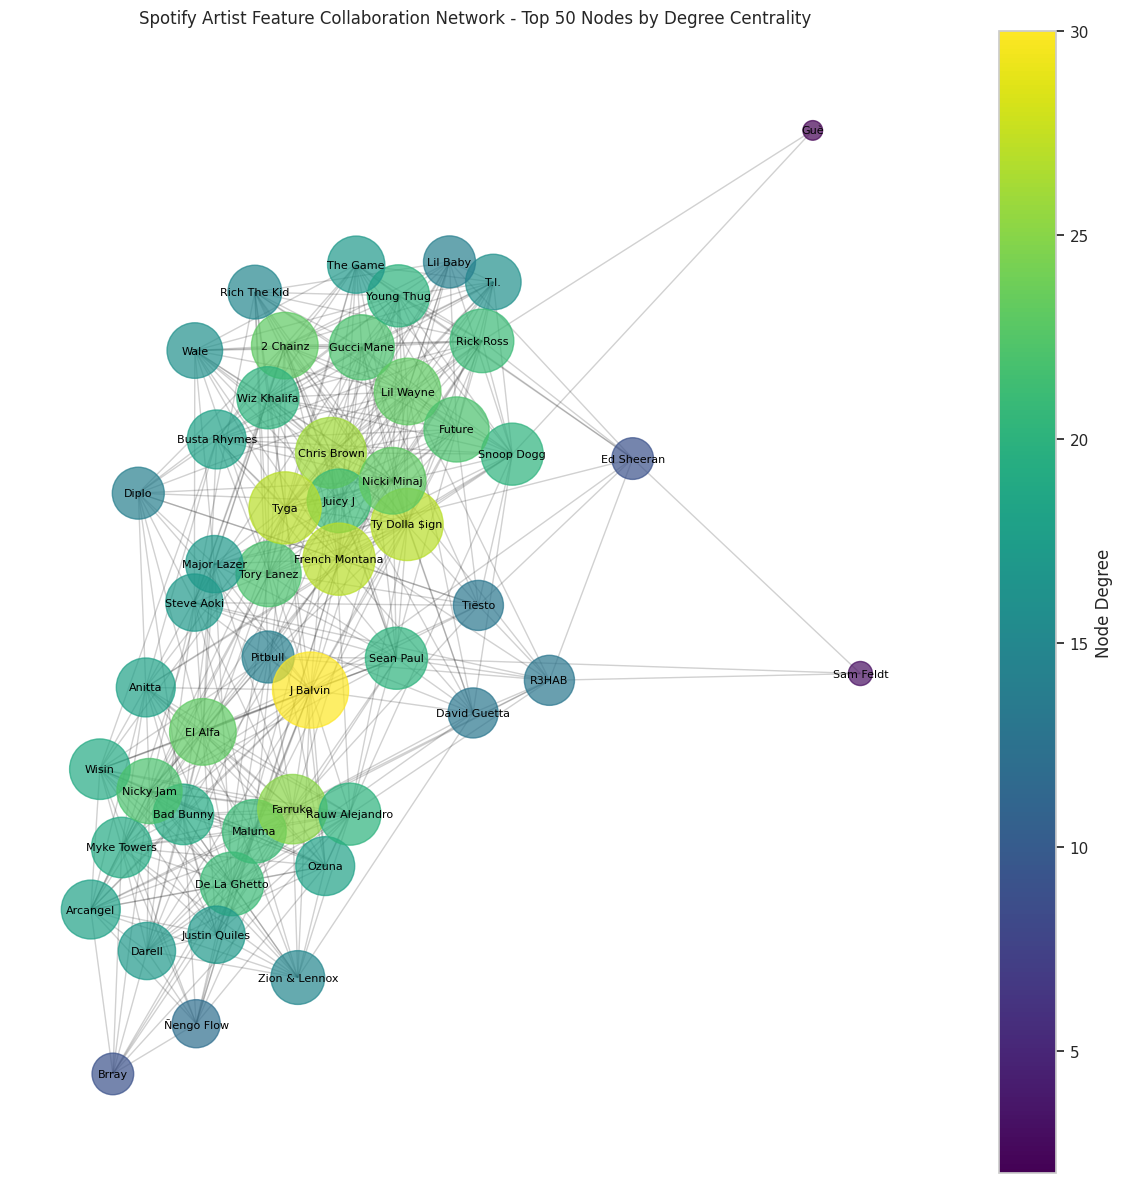

In [20]:
import matplotlib.colors as mcolors

# For large networks, visualization of the entire network might be messy
# We'll visualize a subgraph with the top nodes by degree centrality

# Get top 50 nodes by degree centrality
top_nodes = centrality_df.sort_values('Degree Centrality', ascending=False).head(50)['Node'].tolist()
subgraph = G_lcc.subgraph(top_nodes)

plt.figure(figsize=(12, 12))

# Position nodes using force-directed layout
pos = nx.spring_layout(subgraph, seed=42)

# Get node degrees for sizing
degrees = dict(subgraph.degree())
node_sizes = [v * 100 for v in degrees.values()]

plt.figure(figsize=(12, 12))
ax = plt.gca() # Get the current Axes instance

# Position nodes using force-directed layout
pos = nx.spring_layout(subgraph, seed=42)

# Get node degrees for sizing and coloring
degrees = dict(subgraph.degree())
node_sizes = [v * 100 for v in degrees.values()]
node_colors = list(degrees.values())
cmap = plt.cm.viridis
vmin = min(node_colors)
vmax = max(node_colors)

# Draw the network, explicitly passing the Axes
nodes = nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, alpha=0.7,
                               node_color=node_colors, cmap=cmap, vmin=vmin, vmax=vmax, ax=ax)
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, ax=ax)

# Draw node labels using the Artist Name
id_to_name = dict(zip(selected_nodes['spotify_id'], selected_nodes['name']))
labels = {node: id_to_name.get(node, node) for node in subgraph.nodes()}
nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=8, font_color='black', ax=ax)


plt.title('Spotify Artist Feature Collaboration Network - Top 50 Nodes by Degree Centrality')

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([]) # You need this line for the colorbar to work correctly

# Add the colorbar, specifying the mappable and the Axes
plt.colorbar(sm, label='Node Degree', ax=ax)
plt.axis('off')
plt.tight_layout()
plt.show()

## Summary of Network Analysis

In [21]:
# Create a summary of the network analysis
print("Spotify Artist Feature Collaboration Network Analysis Summary")
print("=================================")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average degree: {avg_degree:.2f}")
print(f"Network density: {nx.density(G):.6f}")
print(f"Global clustering coefficient: {global_clustering:.4f}")
print(f"Average local clustering coefficient: {avg_local_clustering:.4f}")
print(f"Average shortest path length: {path_length_actual:.4f}")
print(f"Network diameter: {diameter}")
print(f"Small-worldness coefficient (σ): {sigma:.4f}")
print(f"Number of connected components: {num_components}")
print(f"Size of the largest connected component: {len(largest_cc)} nodes ({len(largest_cc)/G.number_of_nodes()*100:.2f}% of the network)")
print(f"Number of communities detected: {len(communities)}")

Spotify Artist Feature Collaboration Network Analysis Summary
Number of nodes: 13866
Number of edges: 72207
Average degree: 10.41
Network density: 0.000751
Global clustering coefficient: 0.1664
Average local clustering coefficient: 0.1714
Average shortest path length: 5.4492
Network diameter: 18
Small-worldness coefficient (σ): 160.8817
Number of connected components: 178
Size of the largest connected component: 13450 nodes (97.00% of the network)
Number of communities detected: 34
